In [1]:
import ROOT
import uproot
import numpy as np
import awkward as ak
import math
pdg_db = ROOT.TDatabasePDG.Instance()

Welcome to JupyROOT 6.26/06


In [2]:
file_path = 'Data/merged_mc_v1.3.root'
tree_name = "Tree"

In [3]:
CHARGED_IDS = [11, 13, 211, 321, 2212]
ROOT.gStyle.SetOptStat(1110)

In [4]:
branches = [
    "PassAll", 
    "GenStatus", "GenID", "GenPx", "GenPy", "GenPz", "GenMatchIndex", "GenMatchAngle",
    "RecoCharge", "RecoGoodTrack", "RecoPx", "RecoPy", "RecoPz", 
    "RecoPIDPion", "RecoPIDKaon", "RecoPIDProton", "RecoPIDElectron", "RecoPIDHeavy",
    "RecoMuID", "RecoEleID", "RecoConversionID"
]

In [5]:
total_gen_passed = 0
total_reco_passed = 0

for batch in uproot.iterate(f"{file_path}:{tree_name}", branches, step_size="100 MB"):
    
    # Event Selection
    events = batch[batch["PassAll"] == 1]
    
    # Check Gen
    gen_id_abs = np.abs(events["GenID"])
    
    # Create Charge Mask
    is_charged = (gen_id_abs == CHARGED_IDS[0])
    for pid in CHARGED_IDS[1:]:
        is_charged = is_charged | (gen_id_abs == pid)
        
    mask_gen = (events["GenStatus"] == 1) & is_charged
    
    # ak.sum(mask) counts the number of True values across all events in the batch
    total_gen_passed += ak.sum(mask_gen)

    # Check Reco
    reco_pt = np.sqrt(events["RecoPx"]**2 + events["RecoPy"]**2)
    reco_p  = np.sqrt(events["RecoPx"]**2 + events["RecoPy"]**2 + events["RecoPz"]**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        reco_costh = np.nan_to_num(events["RecoPz"] / reco_p, nan=0.0)

    mask_reco = (
        (events["RecoCharge"] != 0) & 
        (events["RecoGoodTrack"] > 0) & 
        (reco_pt >= 0.4) & 
        (reco_pt <= 100) & 
        (np.abs(reco_costh) < 0.95)
    )
    
    total_reco_passed += ak.sum(mask_reco)


print(f"Total Gen (Status 1 & Charged): {total_gen_passed}")
print(f"Total Reco (Good Tracks): {total_reco_passed}")

Total Gen (Status 1 & Charged): 24063130
Total Reco (Good Tracks): 21710151


In [6]:
# Y-axis (Momentum) points
#custom_y_edges = sorted([
#    0.15, 0.25, 0.3, 0.35, 0.5, 0.6, 0.718, 0.8, 0.9, 0.95, 0.99, 
#    1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 2.0, 2.3, 2.5, 2.6, 2.8, 2.9, 4.0, 8.0
#])

In [7]:
bins_n_uniform = 200
min_x, max_x   = -1.0, 1.0
max_p_gen  = 35.0
max_p_reco = 50.0
max_p_pid  = 15.0

req_x_pos      = [0.05, 0.15, 0.675, 0.70, 0.82, 0.91, 0.94]
custom_x_edges = sorted(list(set([-v for v in req_x_pos] + req_x_pos)))
custom_y_edges = sorted([
    0.15, 0.3, 0.5, 0.65, 0.718, 0.95, 0.99,
    1.2, 2.3, 8.0, 10.0, 15.0, 25.0
])

def make_bins(start, end, n_uniform, custom_points):
    uniform_edges = np.linspace(start, end, n_uniform + 1)
    valid_custom  = [x for x in custom_points if start < x < end]
    combined      = np.unique(np.concatenate((uniform_edges, valid_custom)))
    return combined.astype(np.float64)

bins_x_arr      = make_bins(min_x, max_x,    bins_n_uniform, custom_x_edges)
bins_y_gen_arr  = make_bins(0,     max_p_gen,  bins_n_uniform, custom_y_edges)
bins_y_reco_arr = make_bins(0,     max_p_reco, bins_n_uniform, custom_y_edges)
bins_y_pid_arr  = make_bins(0,     max_p_pid,  bins_n_uniform, custom_y_edges)

nx      = len(bins_x_arr)      - 1
ny_gen  = len(bins_y_gen_arr)  - 1
ny_reco = len(bins_y_reco_arr) - 1
ny_pid  = len(bins_y_pid_arr)  - 1

print(f"X bins: {nx} | Gen Y: {ny_gen} | Reco Y: {ny_reco} | PID Y: {ny_pid}")

X bins: 209 | Gen Y: 213 | Reco Y: 208 | PID Y: 208


In [8]:
h_gen            = ROOT.TH2F("h_gen",           "All Gen; cos(#theta); P",       nx, bins_x_arr, ny_gen,  bins_y_gen_arr)
h_gen_matched    = ROOT.TH2F("h_gen_matched",   "Matched Gen; cos(#theta); P",   nx, bins_x_arr, ny_gen,  bins_y_gen_arr)
h_gen_unmatched  = ROOT.TH2F("h_gen_unmatched", "Unmatched Gen; cos(#theta); P", nx, bins_x_arr, ny_gen,  bins_y_gen_arr)
h_reco           = ROOT.TH2F("h_reco",           "All Reco; cos(#theta); P",      nx, bins_x_arr, ny_reco, bins_y_reco_arr)
h_reco_matched   = ROOT.TH2F("h_reco_matched",   "Matched Reco; cos(#theta); P",  nx, bins_x_arr, ny_reco, bins_y_reco_arr)
h_reco_unmatched = ROOT.TH2F("h_reco_unmatched", "Unmatched Reco; cos(#theta); P",nx, bins_x_arr, ny_reco, bins_y_reco_arr)

species   = ["pion", "kaon", "proton"]
particles = ["pion", "kaon", "proton"]

# PID matrix — pid axis (max 15 GeV)
# IMPORTANT: matched_gen_PID_{p} denominator is filled ONLY for tracks that receive at least one PID tag so that num <= den is guaranteed bin-by-bin for TEfficiency
pid_hists = {}
for p in particles:
    pid_hists[f"matched_gen_PID_{p}"] = ROOT.TH2F(
        f"matched_gen_PID_{p}",
        f"Gen {p} (Any Tag, Heavy-Vetoed); cos(#theta); P",
        nx, bins_x_arr, ny_pid, bins_y_pid_arr)
    for tag in particles:
        pid_hists[f"matched_gen_{p}_tag_as_{tag}"] = ROOT.TH2F(
            f"matched_gen_{p}_tag_as_{tag}",
            f"Gen {p} #rightarrow Tag {tag}; cos(#theta); P",
            nx, bins_x_arr, ny_pid, bins_y_pid_arr)

# Matching efficiency — gen axis (max 35 GeV)
eff_hists = {}
for p in species:
    eff_hists[f"gen_{p}"]             = ROOT.TH2F(f"gen_{p}",
        f"Gen {p}s; cos(#theta); P", nx, bins_x_arr, ny_gen, bins_y_gen_arr)
    eff_hists[f"matched_gen_EFF_{p}"] = ROOT.TH2F(f"matched_gen_EFF_{p}",
        f"Matched Gen {p}s; cos(#theta); P", nx, bins_x_arr, ny_gen, bins_y_gen_arr)

# Fake rate — reco axis (max 50 GeV)
# BOTH numerator and denominator use IDENTICAL heavy-veto tag masks
# so unmatched <= reco is guaranteed bin-by-bin
fake_hists = {}
for p in species:
    fake_hists[f"reco_{p}"]           = ROOT.TH2F(f"reco_{p}",
        f"Reco {p}; cos(#theta); P", nx, bins_x_arr, ny_reco, bins_y_reco_arr)
    fake_hists[f"unmatched_reco_{p}"] = ROOT.TH2F(f"unmatched_reco_{p}",
        f"Fake Reco {p}; cos(#theta); P", nx, bins_x_arr, ny_reco, bins_y_reco_arr)

all_hists = (
    [h_gen, h_reco, h_gen_matched, h_reco_matched, h_gen_unmatched, h_reco_unmatched] +
    list(pid_hists.values()) + list(eff_hists.values()) + list(fake_hists.values())
)
for h in all_hists:
    h.Sumw2()
    h.Reset()

print(f"Histograms: total={len(all_hists)} | PID={len(pid_hists)} | Eff={len(eff_hists)} | Fake={len(fake_hists)}")

Histograms: total=30 | PID=12 | Eff=6 | Fake=6


In [9]:
def fill2d(h, x_arr, y_arr):
    x_arr = np.asarray(x_arr, dtype=np.float64)
    y_arr = np.asarray(y_arr, dtype=np.float64)
    if x_arr.size == 0: return
    w = np.ones(x_arr.size, dtype=np.float64)
    h.FillN(x_arr.size, x_arr, y_arr, w)

# Reset all histograms
for h in all_hists:
    h.Reset()

for batch in uproot.iterate(f"{file_path}:{tree_name}", branches, step_size="100 MB"):

    events     = batch[batch["PassAll"] == 1]
    num_events = len(events)
    if num_events == 0: continue

    # ======================================
    # PART A: RECO — simple good track cuts
    # ======================================
    reco_px = events["RecoPx"]; reco_py = events["RecoPy"]; reco_pz = events["RecoPz"]
    reco_p  = np.sqrt(reco_px**2 + reco_py**2 + reco_pz**2)
    reco_pt = np.sqrt(reco_px**2 + reco_py**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        reco_costh = np.nan_to_num(reco_pz / reco_p, nan=0.0)

    mask_reco_good = (
        (events["RecoCharge"]    != 0) &
        (events["RecoGoodTrack"] >  0) &
        (reco_pt >= 0.4) & (reco_pt <= 100) &
        (np.abs(reco_costh) < 0.95)
    )

    reco_counts     = ak.to_numpy(ak.num(reco_p))
    reco_event_idx  = np.repeat(np.arange(num_events), reco_counts)
    reco_local_idx  = ak.to_numpy(ak.flatten(ak.local_index(reco_p)))
    reco_global_ids = reco_event_idx.astype(np.int64) * 1_000_000 + reco_local_idx.astype(np.int64)

    flat_mask_reco  = ak.to_numpy(ak.flatten(mask_reco_good))
    denom_reco_p    = ak.to_numpy(ak.flatten(reco_p))[flat_mask_reco]
    denom_reco_ct   = ak.to_numpy(ak.flatten(reco_costh))[flat_mask_reco]
    denom_reco_ids  = reco_global_ids[flat_mask_reco]

    # PID values for good tracks
    denom_pid_pi = ak.to_numpy(ak.flatten(events["RecoPIDPion"]))[flat_mask_reco]
    denom_pid_k  = ak.to_numpy(ak.flatten(events["RecoPIDKaon"]))[flat_mask_reco]
    denom_pid_p  = ak.to_numpy(ak.flatten(events["RecoPIDProton"]))[flat_mask_reco]

    # Reco Denominator
    fill2d(h_reco, denom_reco_ct, denom_reco_p)

    is_tag_pi = (denom_pid_pi >= 2)
    is_tag_k  = (denom_pid_k  >= 2)
    is_tag_p  = (denom_pid_p  >= 2)
    tag_masks = {"pion": is_tag_pi, "kaon": is_tag_k, "proton": is_tag_p}

    for s_name, s_mask in tag_masks.items():
        fill2d(fake_hists[f"reco_{s_name}"], denom_reco_ct[s_mask], denom_reco_p[s_mask])

    # =========================================================
    # PART B: GEN — charged and status == 1
    # =========================================================
    gen_px = events["GenPx"]; gen_py = events["GenPy"]; gen_pz = events["GenPz"]
    gen_id = events["GenID"]
    gen_p  = np.sqrt(gen_px**2 + gen_py**2 + gen_pz**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        gen_costh = np.nan_to_num(gen_pz / gen_p, nan=0.0)

    gen_id_abs = np.abs(events["GenID"])
    is_charged = (gen_id_abs == CHARGED_IDS[0])
    for pid in CHARGED_IDS[1:]: is_charged = is_charged | (gen_id_abs == pid)

    mask_gen_all = (events["GenStatus"] == 1) & is_charged

    gen_counts     = ak.to_numpy(ak.num(gen_p))
    gen_event_idx  = np.repeat(np.arange(num_events), gen_counts)
    gen_local_idx  = ak.to_numpy(ak.flatten(ak.local_index(gen_p)))
    gen_global_ids = gen_event_idx.astype(np.int64) * 1_000_000 + gen_local_idx.astype(np.int64)

    flat_mask_gen = ak.to_numpy(ak.flatten(mask_gen_all))
    denom_gen_p   = ak.to_numpy(ak.flatten(gen_p))[flat_mask_gen]
    denom_gen_ct  = ak.to_numpy(ak.flatten(gen_costh))[flat_mask_gen]
    denom_gen_ids = gen_global_ids[flat_mask_gen]
    denom_gen_pdg = ak.to_numpy(ak.flatten(gen_id))[flat_mask_gen]

    # Gen Denominator
    fill2d(h_gen, denom_gen_ct, denom_gen_p)

    is_gen_pi = (np.abs(denom_gen_pdg) == 211)
    is_gen_k  = (np.abs(denom_gen_pdg) == 321)
    is_gen_p  = (np.abs(denom_gen_pdg) == 2212)
    gen_masks = {"pion": is_gen_pi, "kaon": is_gen_k, "proton": is_gen_p}

    for s_name, s_mask in gen_masks.items():
        fill2d(eff_hists[f"gen_{s_name}"], denom_gen_ct[s_mask], denom_gen_p[s_mask])

    # =================================
    # PART C: MATCHING 
    # =================================
    mask_gen_candidates = mask_gen_all & (events["GenMatchAngle"] < 0.01) & (events["GenMatchIndex"] >= 0)

    flat_gen_match_idx  = ak.to_numpy(ak.flatten(events["GenMatchIndex"][mask_gen_candidates]))
    flat_cand_gen_ids   = gen_global_ids[ak.to_numpy(ak.flatten(mask_gen_candidates))]
    flat_cand_gen_p     = ak.to_numpy(ak.flatten(gen_p[mask_gen_candidates]))
    flat_cand_gen_ct    = ak.to_numpy(ak.flatten(gen_costh[mask_gen_candidates]))
    flat_cand_gen_pdg   = ak.to_numpy(ak.flatten(gen_id[mask_gen_candidates]))

    counts_cand          = ak.to_numpy(ak.num(events["GenMatchIndex"][mask_gen_candidates]))
    event_indices_cand   = np.repeat(np.arange(num_events), counts_cand)
    cand_reco_global_ids = event_indices_cand.astype(np.int64) * 1_000_000 + flat_gen_match_idx.astype(np.int64)

    # Filter to candidates whose reco ID actually survived Part A track cuts
    is_good_match = np.isin(cand_reco_global_ids, denom_reco_ids)

    # Arrays to keep duplicates if 2 gen match 1 reco
    final_gen_p_m          = flat_cand_gen_p[is_good_match]
    final_gen_ct_m         = flat_cand_gen_ct[is_good_match]
    final_gen_pdg_m        = flat_cand_gen_pdg[is_good_match]
    final_matched_gen_ids  = flat_cand_gen_ids[is_good_match]
    final_matched_reco_ids = cand_reco_global_ids[is_good_match]

    # Matched Gen
    fill2d(h_gen_matched, final_gen_ct_m, final_gen_p_m)

    is_match_pi = (np.abs(final_gen_pdg_m) == 211)
    is_match_k  = (np.abs(final_gen_pdg_m) == 321)
    is_match_p  = (np.abs(final_gen_pdg_m) == 2212)
    match_masks = {"pion": is_match_pi, "kaon": is_match_k, "proton": is_match_p}

    for s_name, s_mask in match_masks.items():
        fill2d(eff_hists[f"matched_gen_EFF_{s_name}"], final_gen_ct_m[s_mask], final_gen_p_m[s_mask])

    # Reco Matched
    reco_match_mask = np.isin(denom_reco_ids, final_matched_reco_ids)
    fill2d(h_reco_matched, denom_reco_ct[reco_match_mask], denom_reco_p[reco_match_mask])

    # =================================
    # PART D: PID MATRIX
    # =================================
    if len(denom_reco_ids) > 0 and len(final_matched_reco_ids) > 0:

        sort_idx = np.argsort(denom_reco_ids)
        sorted_reco_ids = denom_reco_ids[sort_idx]

        idx_in_sorted = np.searchsorted(sorted_reco_ids, final_matched_reco_ids)
        in_bounds = (idx_in_sorted < len(sorted_reco_ids))
        
        valid = np.zeros_like(in_bounds, dtype=bool)
        if np.any(in_bounds):
            valid[in_bounds] = (sorted_reco_ids[idx_in_sorted[in_bounds]] == final_matched_reco_ids[in_bounds])

        if np.any(valid):
            idx_valid_original = sort_idx[idx_in_sorted[valid]]

            final_gen_p_d   = final_gen_p_m[valid]
            final_gen_ct_d  = final_gen_ct_m[valid]
            final_gen_pdg_d = final_gen_pdg_m[valid]

            match_pid_pi = denom_pid_pi[idx_valid_original]
            match_pid_k  = denom_pid_k[idx_valid_original]
            match_pid_p  = denom_pid_p[idx_valid_original]

            is_true_pi = (np.abs(final_gen_pdg_d) == 211)
            is_true_k  = (np.abs(final_gen_pdg_d) == 321)
            is_true_p  = (np.abs(final_gen_pdg_d) == 2212)

            is_tag_pi_m = (match_pid_pi >= 2)
            is_tag_k_m  = (match_pid_k  >= 2)
            is_tag_p_m  = (match_pid_p  >= 2)

            has_any_tag = is_tag_pi_m | is_tag_k_m | is_tag_p_m

            truth_map = {"pion": is_true_pi, "kaon": is_true_k, "proton": is_true_p}
            tag_map   = {"pion": is_tag_pi_m, "kaon": is_tag_k_m, "proton": is_tag_p_m}

            for true_name, true_mask in truth_map.items():
                denom_mask = true_mask & has_any_tag
                fill2d(pid_hists[f"matched_gen_PID_{true_name}"], final_gen_ct_d[denom_mask], final_gen_p_d[denom_mask])

                for tag_name, tag_mask in tag_map.items():
                    num_mask = true_mask & tag_mask
                    fill2d(pid_hists[f"matched_gen_{true_name}_tag_as_{tag_name}"], final_gen_ct_d[num_mask], final_gen_p_d[num_mask])

    # ====================================
    # PART E: UNMATCHED 
    # ====================================
    unmatched_gen_mask = np.isin(denom_gen_ids, final_matched_gen_ids, invert=True)
    fill2d(h_gen_unmatched, denom_gen_ct[unmatched_gen_mask], denom_gen_p[unmatched_gen_mask])

    unmatched_reco_mask = ~reco_match_mask
    fill2d(h_reco_unmatched, denom_reco_ct[unmatched_reco_mask], denom_reco_p[unmatched_reco_mask])

    for s_name, s_mask in tag_masks.items():
        fake_mask = unmatched_reco_mask & s_mask
        fill2d(fake_hists[f"unmatched_reco_{s_name}"], denom_reco_ct[fake_mask], denom_reco_p[fake_mask])

# ================================================================
# QUICK SANITY CHECK AFTER LOOP
# ================================================================
for s in ["pion", "kaon", "proton"]:
    r = fake_hists[f"reco_{s}"].Integral(0, fake_hists[f"reco_{s}"].GetNbinsX()+1,
                                        0, fake_hists[f"reco_{s}"].GetNbinsY()+1)
    u = fake_hists[f"unmatched_reco_{s}"].Integral(0, fake_hists[f"unmatched_reco_{s}"].GetNbinsX()+1,
                                                  0, fake_hists[f"unmatched_reco_{s}"].GetNbinsY()+1)
    e = eff_hists[f"matched_gen_EFF_{s}"].Integral(0, eff_hists[f"matched_gen_EFF_{s}"].GetNbinsX()+1,
                                                  0, eff_hists[f"matched_gen_EFF_{s}"].GetNbinsY()+1)
    g = eff_hists[f"gen_{s}"].Integral(0, eff_hists[f"gen_{s}"].GetNbinsX()+1,
                                      0, eff_hists[f"gen_{s}"].GetNbinsY()+1)
    d = pid_hists[f"matched_gen_PID_{s}"].Integral(0, pid_hists[f"matched_gen_PID_{s}"].GetNbinsX()+1,
                                                  0, pid_hists[f"matched_gen_PID_{s}"].GetNbinsY()+1)
    t = pid_hists[f"matched_gen_{s}_tag_as_{s}"].Integral(0, pid_hists[f"matched_gen_{s}_tag_as_{s}"].GetNbinsX()+1,
                                                         0, pid_hists[f"matched_gen_{s}_tag_as_{s}"].GetNbinsY()+1)

    print(f"\n{s.upper()}")
    print(f"  reco (tagged)          : {r:.0f}")
    print(f"  unmatched_reco (fake)  : {u:.0f}   fake_rate={u/r:.4f}" if r > 0 else "  reco=0!")
    print(f"  gen (all)              : {g:.0f}")
    print(f"  matched_gen_EFF        : {e:.0f}   match_eff={e/g:.4f}" if g > 0 else "  gen=0!")
    print(f"  matched_gen_PID (denom): {d:.0f}")
    print(f"  tag_as_{s} (num)       : {t:.0f}   tag_rate={t/d:.4f}" if d > 0 else "  PID denom=0!")
print("=" * 55)


PION
  reco (tagged)          : 10558608
  unmatched_reco (fake)  : 1924120   fake_rate=0.1822
  gen (all)              : 19640163
  matched_gen_EFF        : 13417992   match_eff=0.6832
  matched_gen_PID (denom): 8998329
  tag_as_pion (num)       : 8281830   tag_rate=0.9204

KAON
  reco (tagged)          : 1945352
  unmatched_reco (fake)  : 233247   fake_rate=0.1199
  gen (all)              : 2886534
  matched_gen_EFF        : 2344788   match_eff=0.8123
  matched_gen_PID (denom): 1396715
  tag_as_kaon (num)       : 1079463   tag_rate=0.7729

PROTON
  reco (tagged)          : 932646
  unmatched_reco (fake)  : 254404   fake_rate=0.2728
  gen (all)              : 905179
  matched_gen_EFF        : 731588   match_eff=0.8082
  matched_gen_PID (denom): 431299
  tag_as_proton (num)       : 337529   tag_rate=0.7826


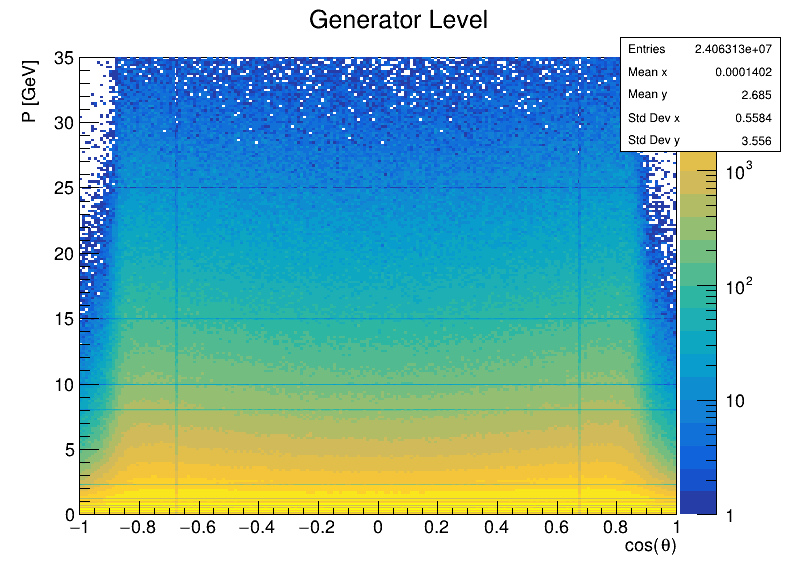

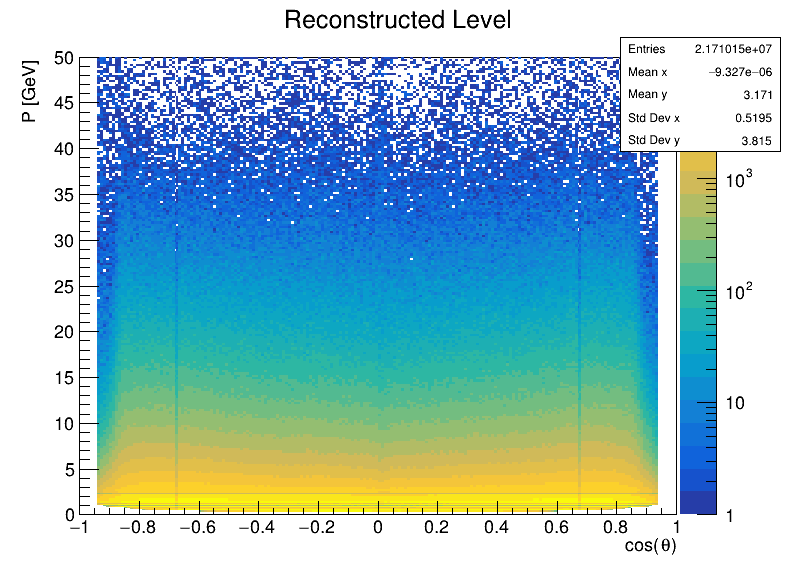

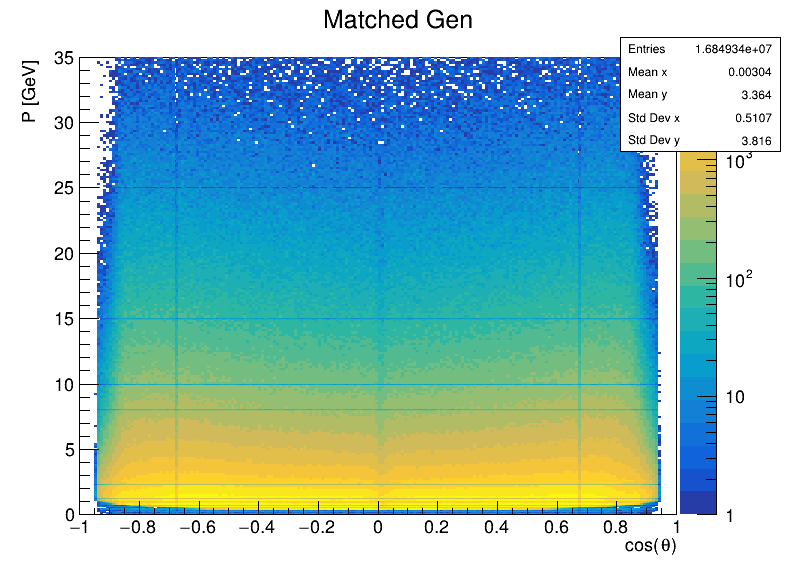

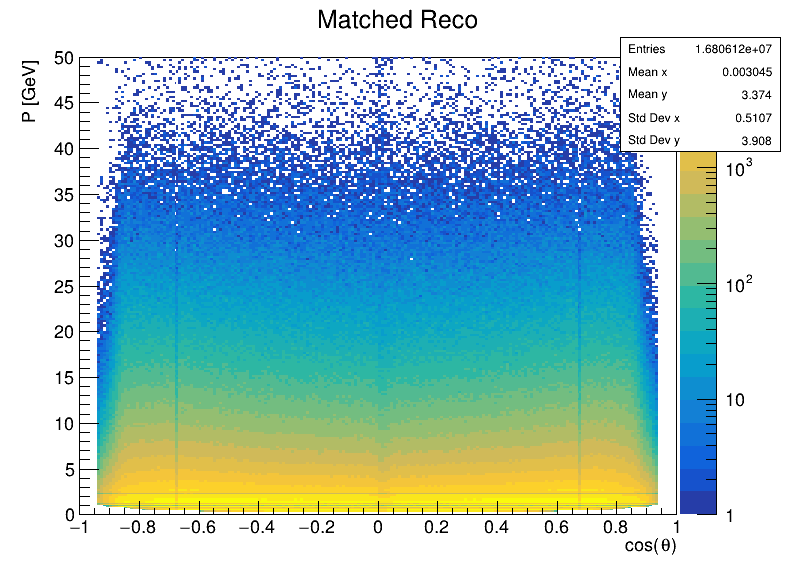

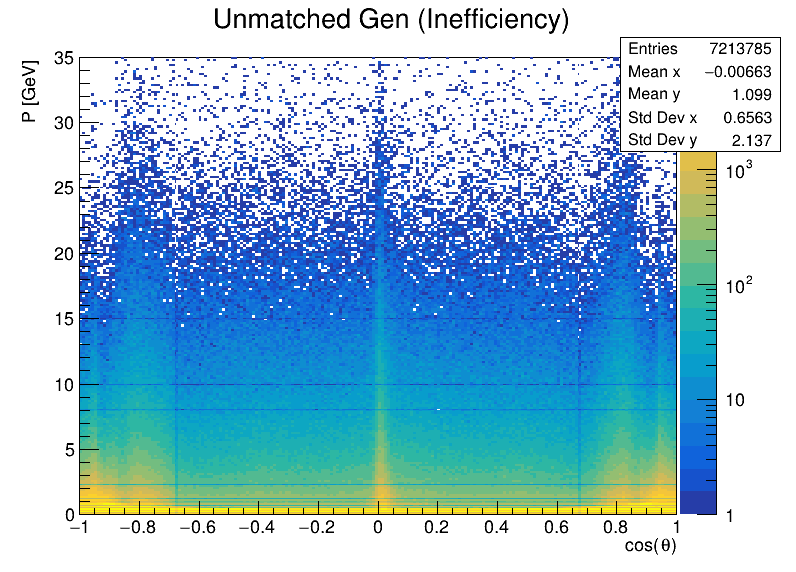

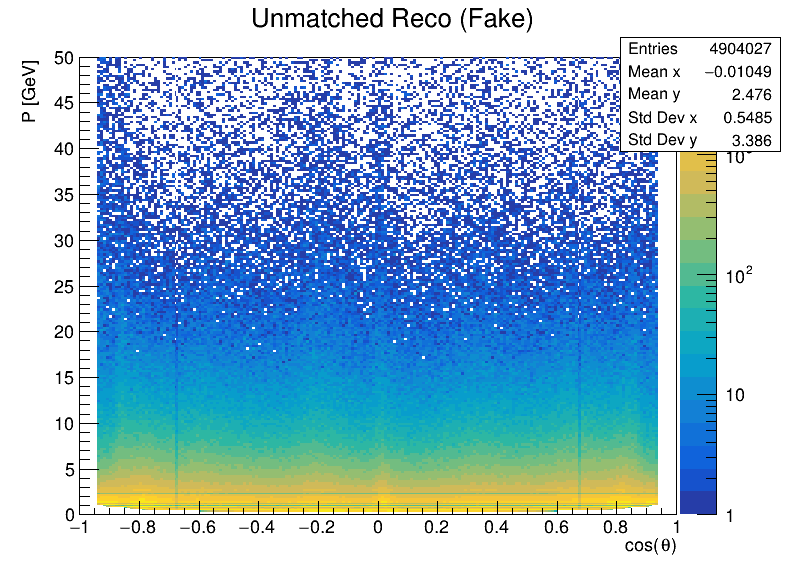

In [10]:
def draw_canvas(h, name, title):
    c = ROOT.TCanvas(name, title, 800, 600)
    ROOT.gPad.SetLogz()
    ROOT.gPad.SetRightMargin(0.15)
    h.SetTitle(title)
    h.SetStats(1)
    h.Draw("COLZ")
    c.Update()
    c.Draw()
    return c


c1 = draw_canvas(h_gen, "c_gen", "Generator Level; cos(#theta); P [GeV]")
c2 = draw_canvas(h_reco, "c_reco", "Reconstructed Level; cos(#theta); P [GeV]")
c3 = draw_canvas(h_gen_matched, "c_gen_m", "Matched Gen; cos(#theta); P [GeV]")
c4 = draw_canvas(h_reco_matched, "c_reco_m", "Matched Reco; cos(#theta); P [GeV]")
c5 = draw_canvas(h_gen_unmatched, "c_gen_u", "Unmatched Gen (Inefficiency); cos(#theta); P [GeV]")
c6 = draw_canvas(h_reco_unmatched, "c_reco_u", "Unmatched Reco (Fake); cos(#theta); P [GeV]")

Overall Gen Efficiency: 0.7002  (16849345/24063130)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_gen


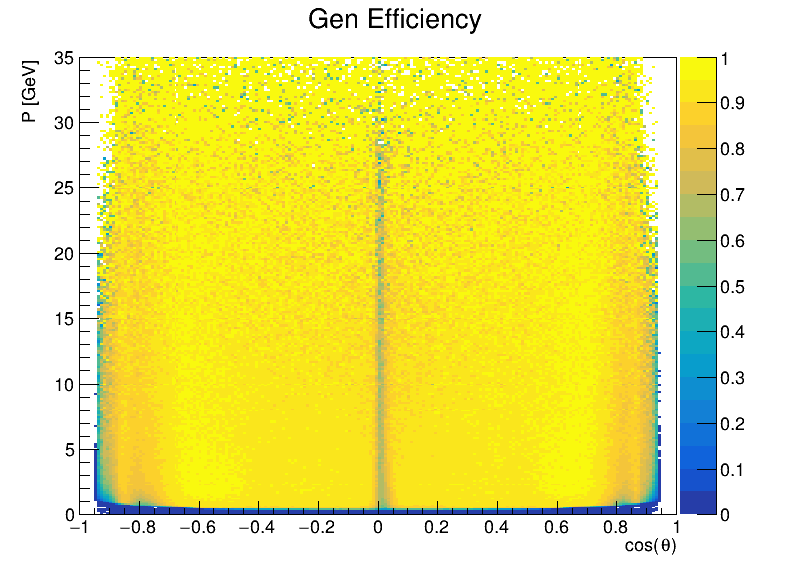

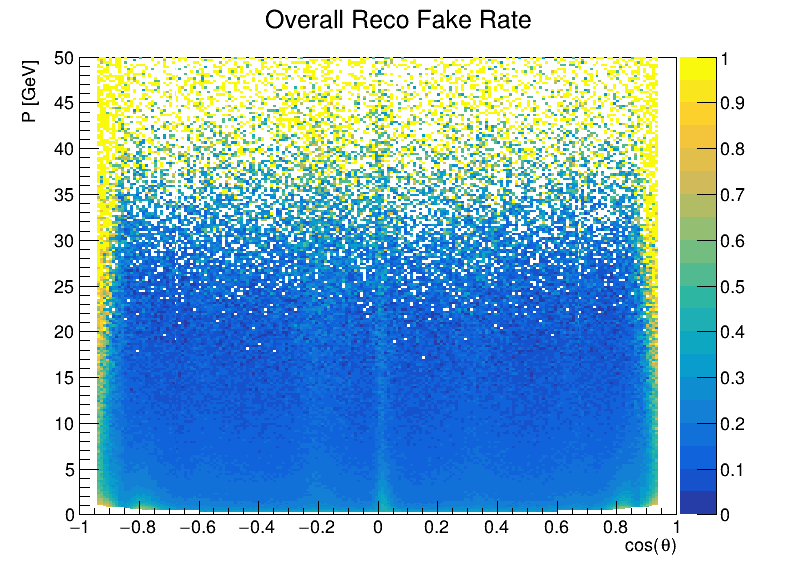

In [11]:
canvas_list = []
eff_list    = []
keep_alive  = []

pEff_gen = ROOT.TEfficiency(h_gen_matched, h_gen)
pEff_gen.SetStatisticOption(ROOT.TEfficiency.kFCP)
pEff_gen.SetName("GenEfficiency")
pEff_gen.SetTitle("Gen Efficiency; cos(#theta); P [GeV]")
c_gen = ROOT.TCanvas("c_gen", "Gen Efficiency", 800, 600)
ROOT.gPad.SetRightMargin(0.15)
pEff_gen.Draw("COLZ")
ROOT.gPad.Update()
if pEff_gen.GetPaintedHistogram():
    pEff_gen.GetPaintedHistogram().SetMinimum(0)
    pEff_gen.GetPaintedHistogram().SetMaximum(1)
c_gen.Draw()
canvas_list.append(c_gen)
eff_list.append(pEff_gen)

n = h_gen_matched.Integral(0, h_gen_matched.GetNbinsX()+1, 0, h_gen_matched.GetNbinsY()+1)
d = h_gen.Integral(0, h_gen.GetNbinsX()+1, 0, h_gen.GetNbinsY()+1)
print(f"Overall Gen Efficiency: {n/d:.4f}  ({n:.0f}/{d:.0f})")


if ROOT.TEfficiency.CheckConsistency(h_reco_unmatched, h_reco):
    pFAKE_reco = ROOT.TEfficiency(h_reco_unmatched, h_reco)
    pFAKE_reco.SetStatisticOption(ROOT.TEfficiency.kFCP)
    pFAKE_reco.SetName("RecoFakeRate_Overall")
    pFAKE_reco.SetTitle("Overall Reco Fake Rate; cos(#theta); P [GeV]")
    c_reco_FAKE = ROOT.TCanvas("c_reco_FAKE", "Overall Reco Fake Rate", 800, 600)
    ROOT.gPad.SetRightMargin(0.15)
    pFAKE_reco.Draw("COLZ")
    ROOT.gPad.Update()
    if pFAKE_reco.GetPaintedHistogram():
        pFAKE_reco.GetPaintedHistogram().SetMinimum(0)
        pFAKE_reco.GetPaintedHistogram().SetMaximum(1)
    c_reco_FAKE.Draw()
    canvas_list.append(c_reco_FAKE)
    eff_list.append(pFAKE_reco)
else:
    print("WARNING: h_reco_unmatched > h_reco in some bins — check loop logic")

----------------------------------------
SPECIES MATCHING EFFICIENCIES
Pion Matching Eff: 0.6832  (13417992/19640163)
Kaon Matching Eff: 0.8123  (2344788/2886534)
Proton Matching Eff: 0.8082  (731588/905179)
----------------------------------------


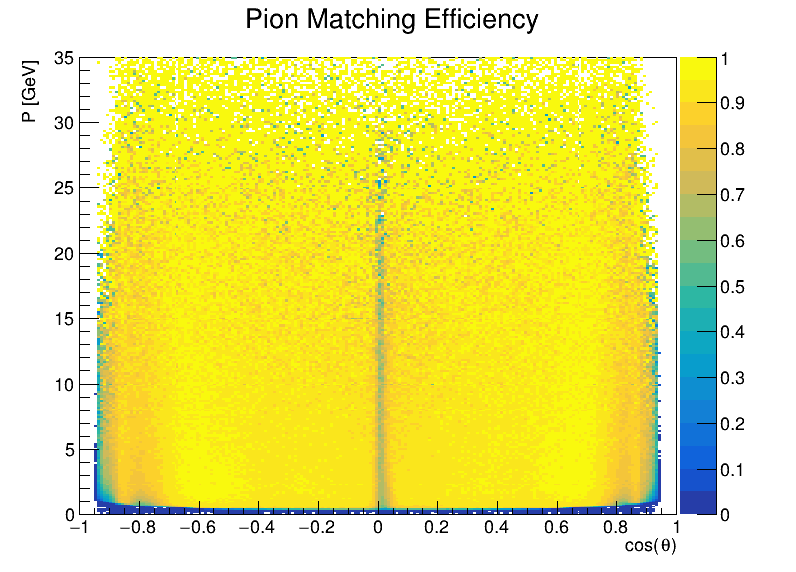

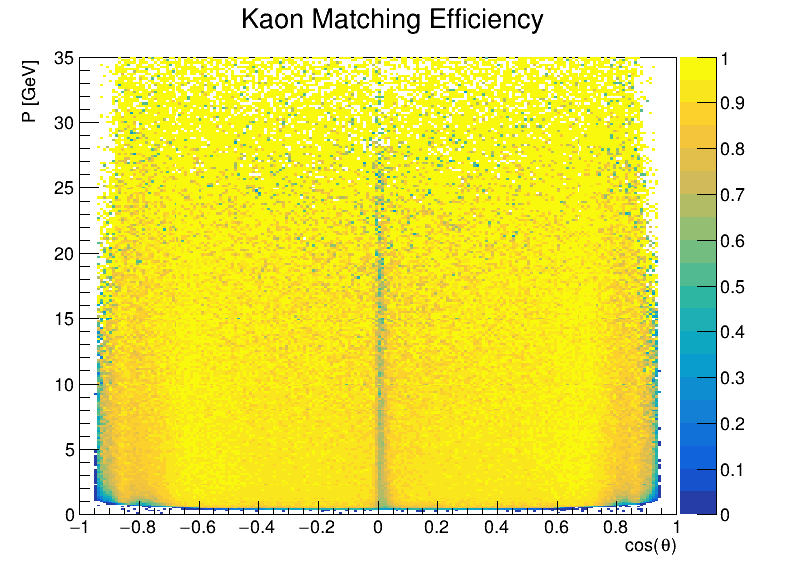

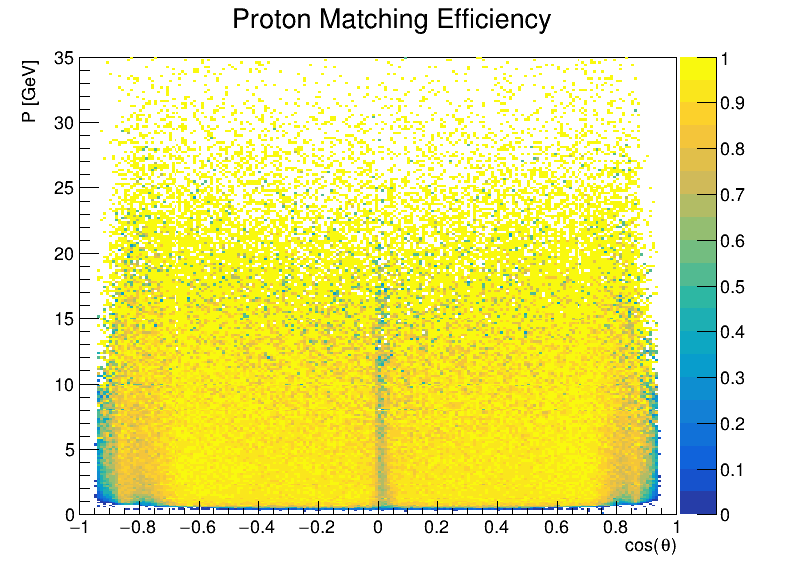

In [12]:
def draw_species_eff(species_name):
    num = eff_hists[f"matched_gen_EFF_{species_name}"]
    den = eff_hists[f"gen_{species_name}"]
    if not ROOT.TEfficiency.CheckConsistency(num, den):
        print(f"ERROR {species_name} eff: num > den in some bins")
        return
    pEff = ROOT.TEfficiency(num, den)
    pEff.SetStatisticOption(ROOT.TEfficiency.kFCP)
    pEff.SetName(f"Eff_{species_name}")
    pEff.SetTitle(f"{species_name.capitalize()} Matching Efficiency; cos(#theta); P [GeV]")
    c = ROOT.TCanvas(f"c_eff_{species_name}", f"{species_name} Matching Efficiency", 800, 600)
    ROOT.gPad.SetRightMargin(0.15)
    pEff.Draw("COLZ")
    ROOT.gPad.Update()
    if pEff.GetPaintedHistogram():
        pEff.GetPaintedHistogram().SetMinimum(0)
        pEff.GetPaintedHistogram().SetMaximum(1)
    c.Draw()
    canvas_list.append(c)
    eff_list.append(pEff)
    n = num.Integral(0, num.GetNbinsX()+1, 0, num.GetNbinsY()+1)
    d = den.Integral(0, den.GetNbinsX()+1, 0, den.GetNbinsY()+1)
    print(f"{species_name.capitalize()} Matching Eff: {n/d:.4f}  ({n:.0f}/{d:.0f})")

print("-" * 40)
print("SPECIES MATCHING EFFICIENCIES")
for s in species:
    draw_species_eff(s)
print("-" * 40)

----------------------------------------
SPECIES FAKE RATES
Pion Fake Rate: 0.1822  (1924120/10558608)
Kaon Fake Rate: 0.1199  (233247/1945352)
Proton Fake Rate: 0.2728  (254404/932646)
----------------------------------------


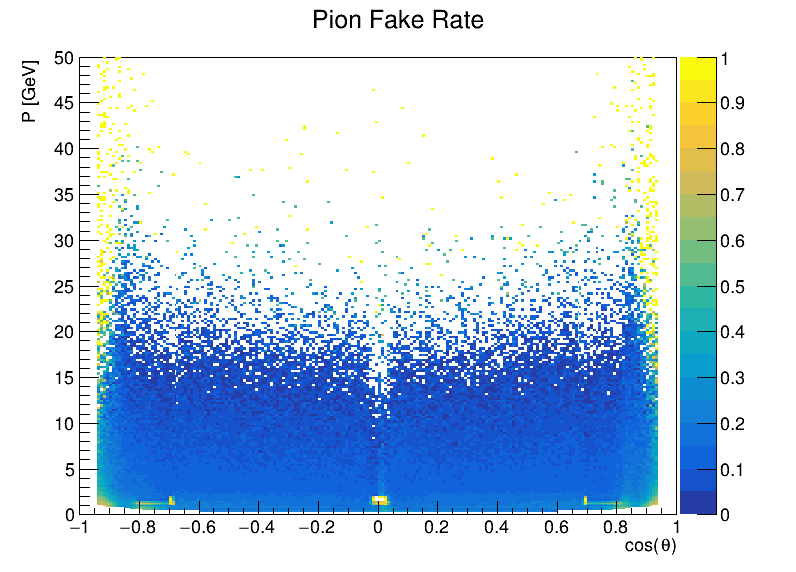

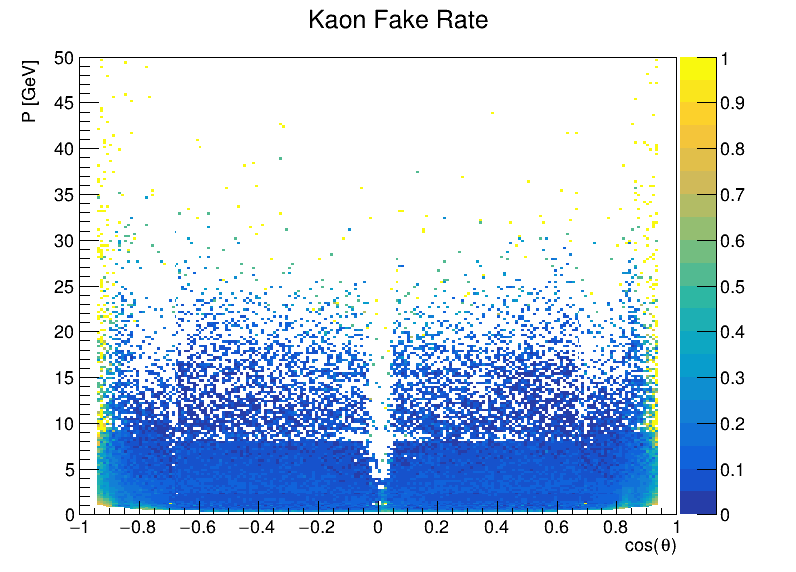

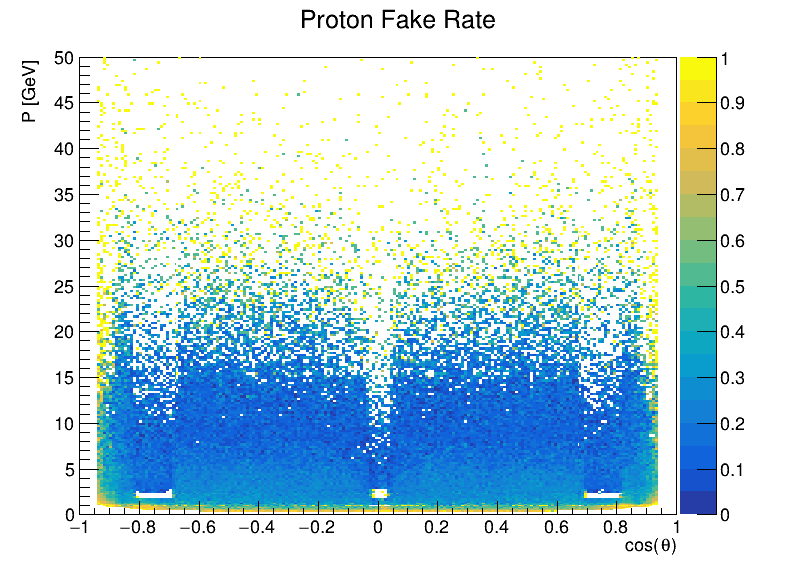

In [13]:
def draw_species_fake(species_name):
    num = fake_hists[f"unmatched_reco_{species_name}"]
    den = fake_hists[f"reco_{species_name}"]

    n_integral = num.Integral(0, num.GetNbinsX()+1, 0, num.GetNbinsY()+1)
    d_integral = den.Integral(0, den.GetNbinsX()+1, 0, den.GetNbinsY()+1)

    if d_integral == 0:
        print(f"WARNING {species_name} fake rate: denominator is empty")
        return

    if not ROOT.TEfficiency.CheckConsistency(num, den):
        # Find and report the offending bins for debugging
        n_bad = 0
        for bx in range(0, num.GetNbinsX()+2):
            for by in range(0, num.GetNbinsY()+2):
                if num.GetBinContent(bx, by) > den.GetBinContent(bx, by):
                    n_bad += 1
        print(f"ERROR {species_name} fake rate: num > den in {n_bad} bins")
        print(f"  num integral={n_integral:.0f}  den integral={d_integral:.0f}")
        print(f"  This means the tag masks in Part A and Part E are inconsistent")
        return

    pEff = ROOT.TEfficiency(num, den)
    pEff.SetStatisticOption(ROOT.TEfficiency.kFCP)
    pEff.SetName(f"Fake_{species_name}")
    pEff.SetTitle(f"{species_name.capitalize()} Fake Rate; cos(#theta); P [GeV]")
    c = ROOT.TCanvas(f"c_fake_{species_name}", f"{species_name} Fake Rate", 800, 600)
    ROOT.gPad.SetRightMargin(0.15)
    pEff.Draw("COLZ")
    ROOT.gPad.Update()
    if pEff.GetPaintedHistogram():
        pEff.GetPaintedHistogram().SetMinimum(0)
        pEff.GetPaintedHistogram().SetMaximum(1)
    c.Draw()
    canvas_list.append(c)
    eff_list.append(pEff)
    print(f"{species_name.capitalize()} Fake Rate: {n_integral/d_integral:.4f}  ({n_integral:.0f}/{d_integral:.0f})")

print("-" * 40)
print("SPECIES FAKE RATES")
for s in species:
    draw_species_fake(s)
print("-" * 40)

----------------------------------------
PID MATRIX (9 combinations)
  matched_gen_PID_pion: 8998329 entries
    Eff_pion_ID: 8281830 entries  (frac=0.9204)
    MisID_pion_as_kaon: 562322 entries  (frac=0.0625)
    MisID_pion_as_proton: 154177 entries  (frac=0.0171)
  matched_gen_PID_kaon: 1396715 entries
    MisID_kaon_as_pion: 135042 entries  (frac=0.0967)
    Eff_kaon_ID: 1079463 entries  (frac=0.7729)
    MisID_kaon_as_proton: 182210 entries  (frac=0.1305)
  matched_gen_PID_proton: 431299 entries
    MisID_proton_as_pion: 33384 entries  (frac=0.0774)
    MisID_proton_as_kaon: 60386 entries  (frac=0.1400)
    Eff_proton_ID: 337529 entries  (frac=0.7826)
----------------------------------------
All PID matrix plots generated.


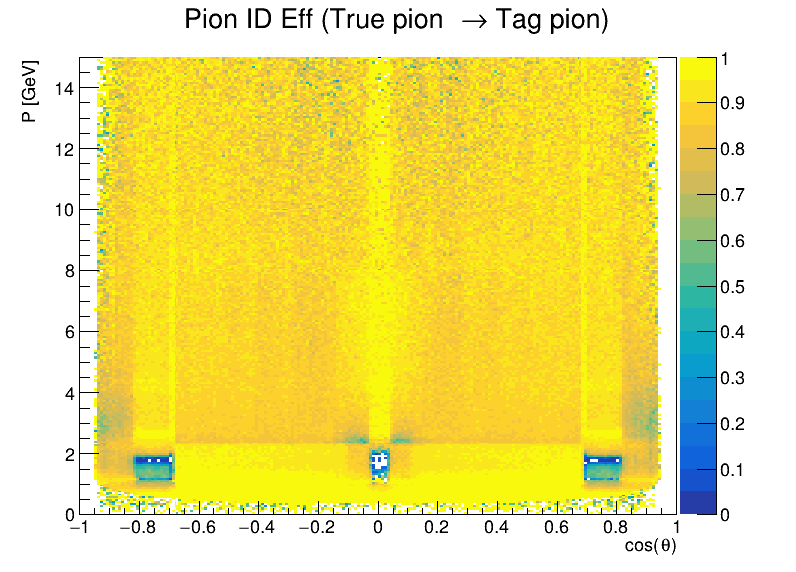

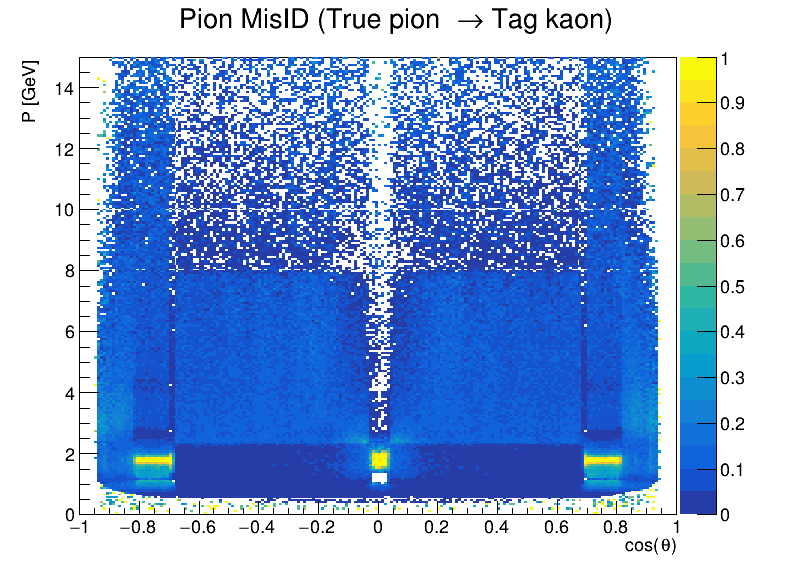

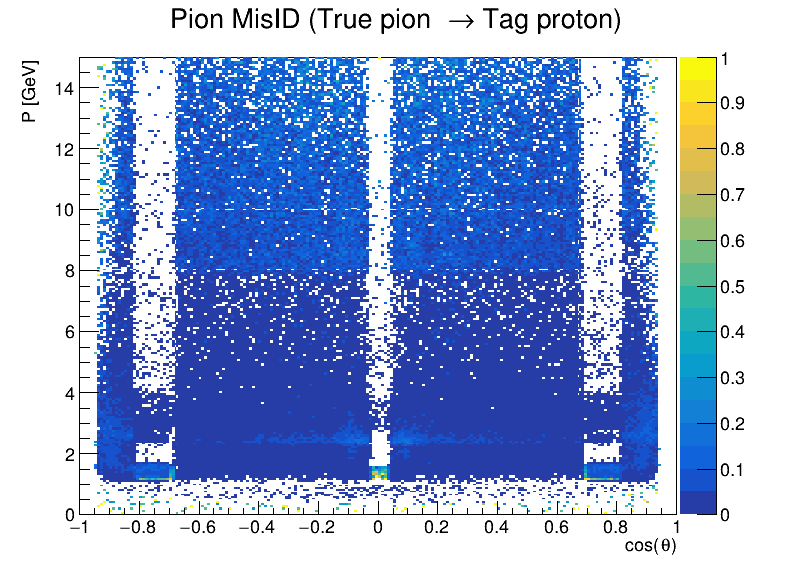

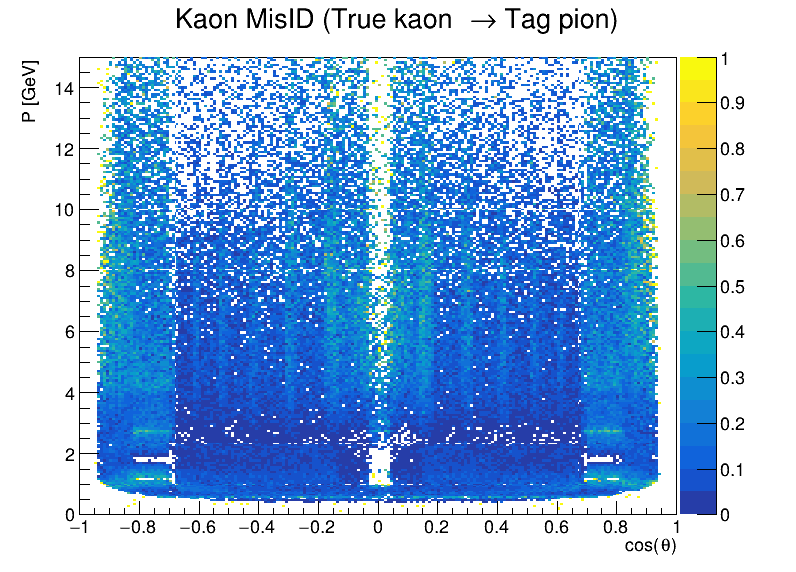

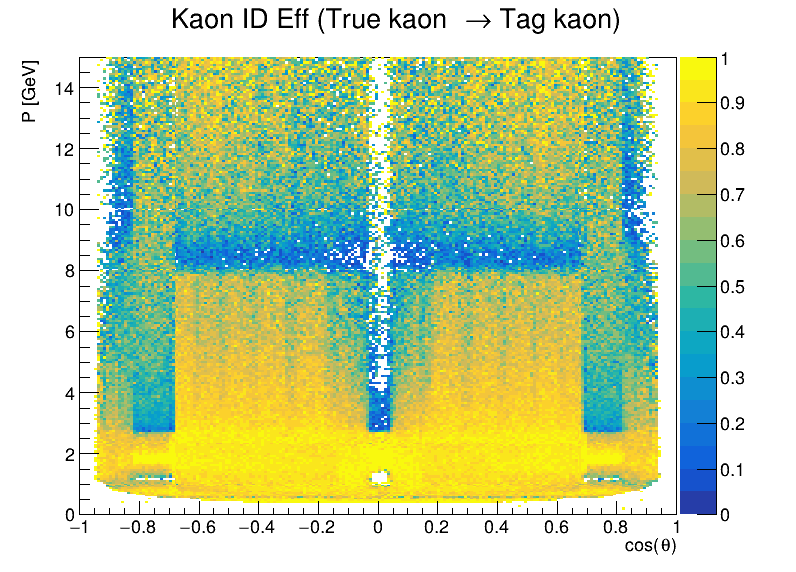

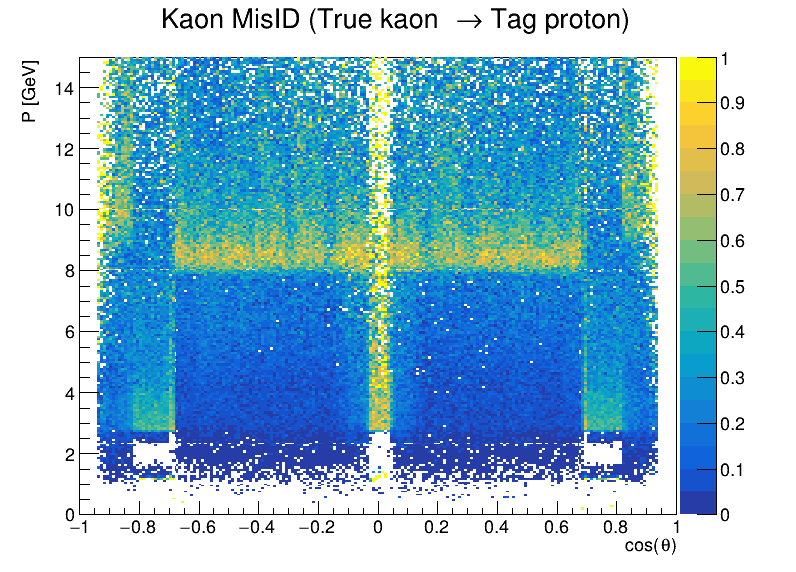

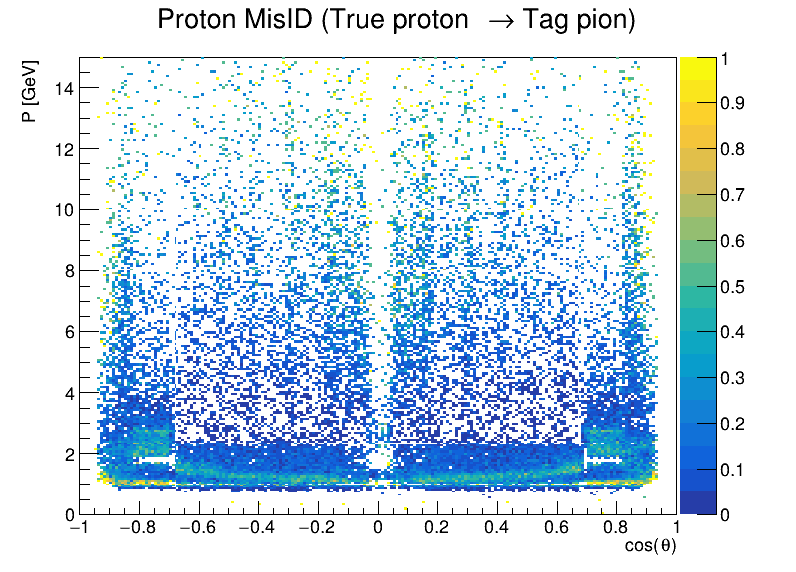

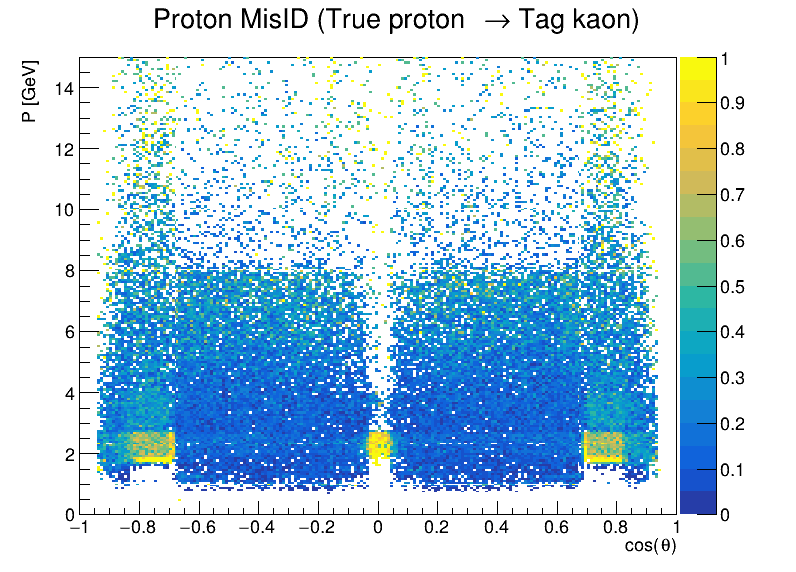

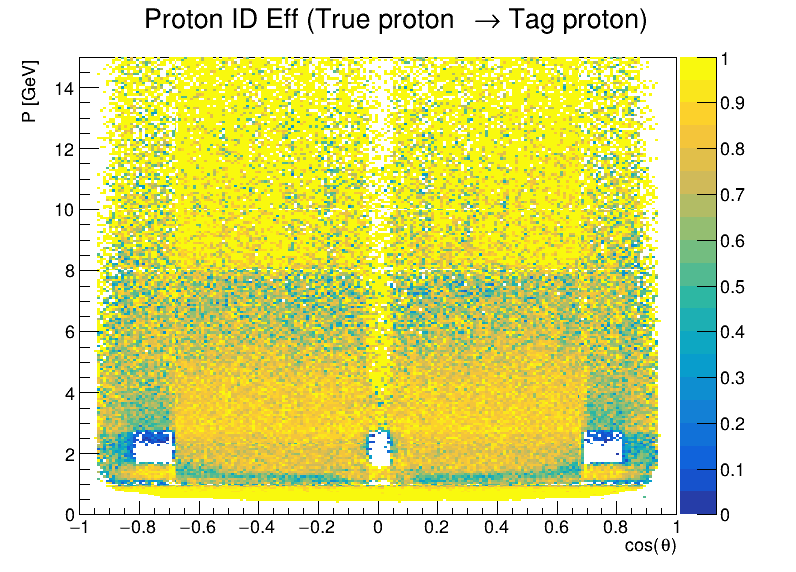

In [14]:
def draw_pid_efficiency(num, denom, name, title):
    n_integral = num.Integral(0, num.GetNbinsX()+1, 0, num.GetNbinsY()+1)
    d_integral = denom.Integral(0, denom.GetNbinsX()+1, 0, denom.GetNbinsY()+1)

    if d_integral == 0:
        print(f"WARNING {name}: denominator empty, skipping")
        return None

    if not ROOT.TEfficiency.CheckConsistency(num, denom):
        n_bad = sum(
            1 for bx in range(0, num.GetNbinsX()+2)
            for by in range(0, num.GetNbinsY()+2)
            if num.GetBinContent(bx, by) > denom.GetBinContent(bx, by)
        )
        print(f"ERROR {name}: num > den in {n_bad} bins — skipping")
        return None

    pEff = ROOT.TEfficiency(num, denom)
    pEff.SetName(name)
    pEff.SetTitle(title)
    c = ROOT.TCanvas(f"c_{name}", title, 800, 600)
    ROOT.gPad.SetRightMargin(0.15)
    pEff.Draw("COLZ")
    c.Update()
    if pEff.GetPaintedHistogram():
        pEff.GetPaintedHistogram().SetMinimum(0.0)
        pEff.GetPaintedHistogram().SetMaximum(1.0)
    c.Draw()
    keep_alive.append(pEff)
    keep_alive.append(c)
    return c

print("-" * 40)
print("PID MATRIX (9 combinations)")
for true_p in particles:
    denom_hist = pid_hists[f"matched_gen_PID_{true_p}"]
    d_int = denom_hist.Integral(0, denom_hist.GetNbinsX()+1, 0, denom_hist.GetNbinsY()+1)
    print(f"  matched_gen_PID_{true_p}: {d_int:.0f} entries")
    for tag_p in particles:
        num_hist = pid_hists[f"matched_gen_{true_p}_tag_as_{tag_p}"]
        n_int = num_hist.Integral(0, num_hist.GetNbinsX()+1, 0, num_hist.GetNbinsY()+1)
        if true_p == tag_p:
            name  = f"Eff_{true_p}_ID"
            title = f"{true_p.capitalize()} ID Eff (True {true_p} #rightarrow Tag {tag_p}); cos(#theta); P [GeV]"
        else:
            name  = f"MisID_{true_p}_as_{tag_p}"
            title = f"{true_p.capitalize()} MisID (True {true_p} #rightarrow Tag {tag_p}); cos(#theta); P [GeV]"
        print(f"    {name}: {n_int:.0f} entries  (frac={n_int/d_int:.4f})" if d_int > 0 else f"    {name}: denom empty")
        draw_pid_efficiency(num_hist, denom_hist, name, title)

print("-" * 40)
print("All PID matrix plots generated.")

Global efficiency: 0.7741136392833011 Num: 16806124.0 Den: 21710151.0


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_reco


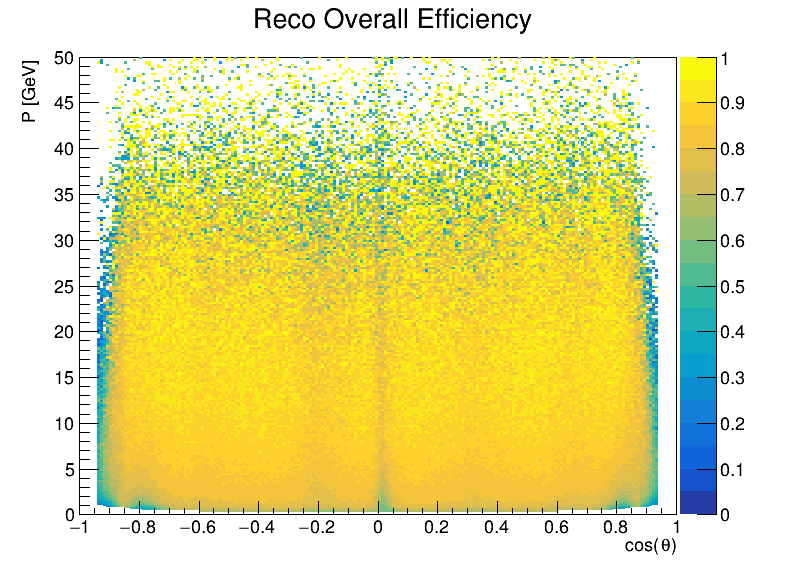

In [15]:
if ROOT.TEfficiency.CheckConsistency(h_reco_matched, h_reco):
    pEff_reco = ROOT.TEfficiency(h_reco_matched, h_reco)
    pEff_reco.SetStatisticOption(ROOT.TEfficiency.kFCP)  # Clopper-Pearson
    pEff_reco.SetName("RecoEff")
    pEff_reco.SetTitle("Reco Overall Efficiency; cos(#theta); P [GeV]")

    c_reco = ROOT.TCanvas("c_reco", "Reco Efficiency", 800, 600)
    ROOT.gPad.SetRightMargin(0.15)
    pEff_reco.Draw("COLZ")
    ROOT.gPad.Update()
    pEff_reco.GetPaintedHistogram().SetMinimum(0)
    pEff_reco.GetPaintedHistogram().SetMaximum(1)
    c_reco.Draw()
else:
    print("Error: Histograms are still inconsistent. Check binning or cuts.")

num_total = h_reco_matched.Integral(0, h_reco_matched.GetNbinsX()+1, 0, h_reco_matched.GetNbinsY()+1)
den_total = h_reco.Integral(0, h_reco.GetNbinsX()+1, 0, h_reco.GetNbinsY()+1)
print("Global efficiency:", num_total/den_total if den_total > 0 else 0, "Num:", num_total, "Den:", den_total)

In [16]:
# SAVE TO ROOT FILE - UNIFORM BINNING

output_filename = "MC_Merged_Matched_EfficiencyUniformBinning_FakeRate.root"
f_out = ROOT.TFile(output_filename, "RECREATE")
f_out.cd()

for h in all_hists:
    h.Write()

written_names = set()
for obj in ([pEff_gen]    if 'pEff_gen'    in locals() else []) + \
           ([pFAKE_reco]  if 'pFAKE_reco'  in locals() else []) + \
           ([pEff_reco]   if 'pEff_reco'   in locals() else []) + \
           list(eff_list) + keep_alive:
    if isinstance(obj, ROOT.TEfficiency):
        if obj.GetName() not in written_names:
            obj.Write()
            written_names.add(obj.GetName())

f_out.Close()
print(f"Saved: {output_filename}")

Saved: MC_Merged_Matched_EfficiencyUniformBinning_FakeRate.root


In [17]:
f = ROOT.TFile.Open("MC_Merged_Matched_EfficiencyUniformBinning_FakeRate.root")

if not f or f.IsZombie():
    print("Error: Could not open file.")
else:
    print(f"File Size: {f.GetSize() / 1024:.2f} KB")
    print("-" * 100)
    # Header for the table
    print(f"{'Class':<15} | {'Name':<35} | {'Title (Description)'}")
    print("-" * 100)

    # Loop over keys and print Class, Name, and Title
    for key in f.GetListOfKeys():
        print(f"{key.GetClassName():<15} | {key.GetName():<35} | {key.GetTitle()}")

    print("-" * 100)
    f.Close()

File Size: 6781.08 KB
----------------------------------------------------------------------------------------------------
Class           | Name                                | Title (Description)
----------------------------------------------------------------------------------------------------
TH2F            | h_gen                               | Generator Level
TH2F            | h_reco                              | Reconstructed Level
TH2F            | h_gen_matched                       | Matched Gen
TH2F            | h_reco_matched                      | Matched Reco
TH2F            | h_gen_unmatched                     | Unmatched Gen (Inefficiency)
TH2F            | h_reco_unmatched                    | Unmatched Reco (Fake)
TH2F            | matched_gen_PID_pion                | Gen pion (Any Tag, Heavy-Vetoed)
TH2F            | matched_gen_pion_tag_as_pion        | Gen pion #rightarrow Tag pion
TH2F            | matched_gen_pion_tag_as_kaon        | Gen pion #rightarrow 


--- Generating Momentum (P) Plots ---
[PION  ]     P-projection Global Ratio = 1.0409
[KAON  ]     P-projection Global Ratio = 1.0462
[PROTON]     P-projection Global Ratio = 1.0468

--- Generating Angular (cosTheta) Plots ---
[PION  ] costh-projection Global Ratio = 1.0191
[KAON  ] costh-projection Global Ratio = 1.0056
[PROTON] costh-projection Global Ratio = 1.0029


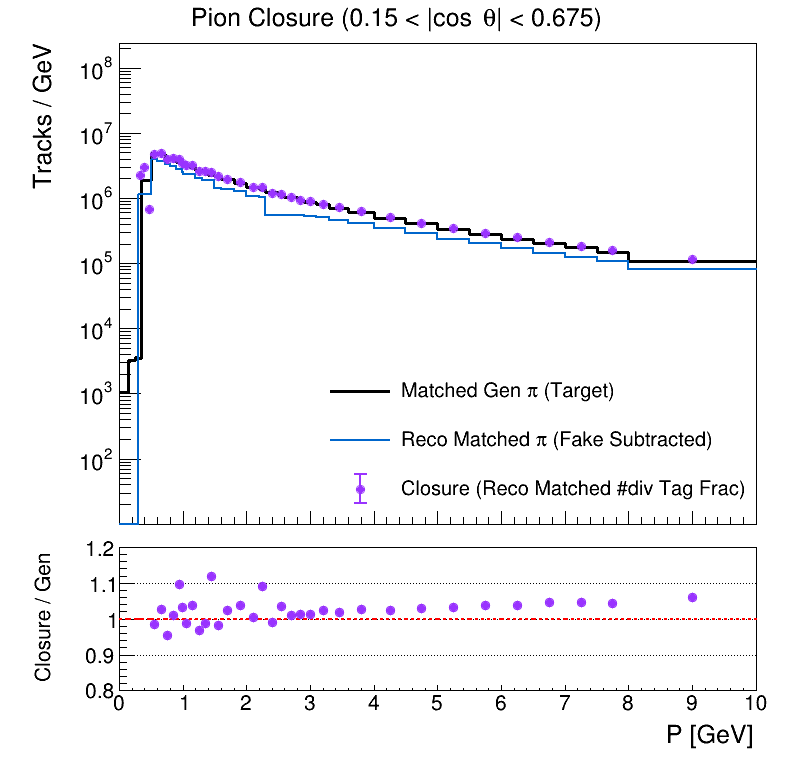

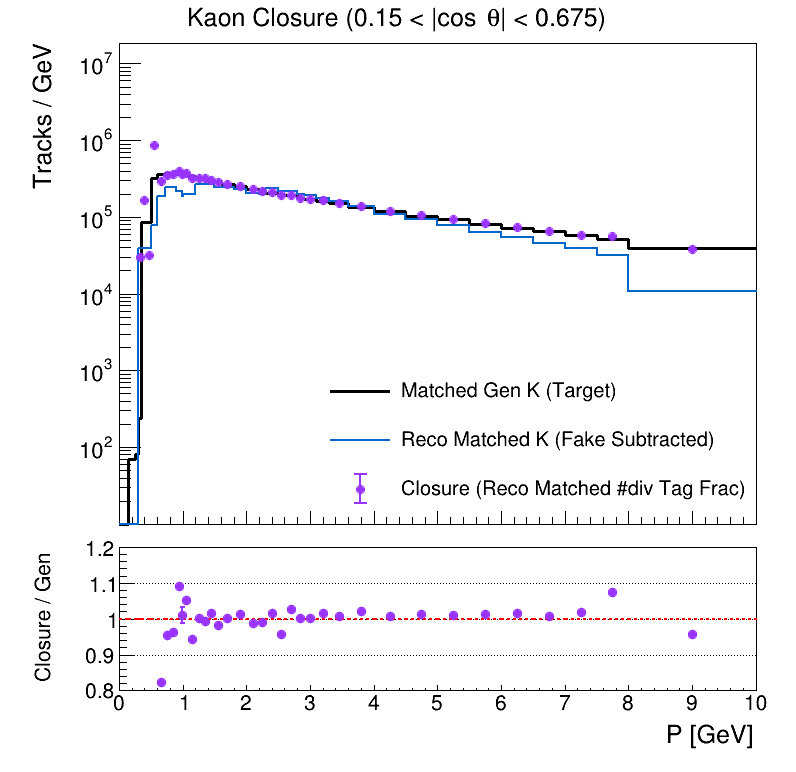

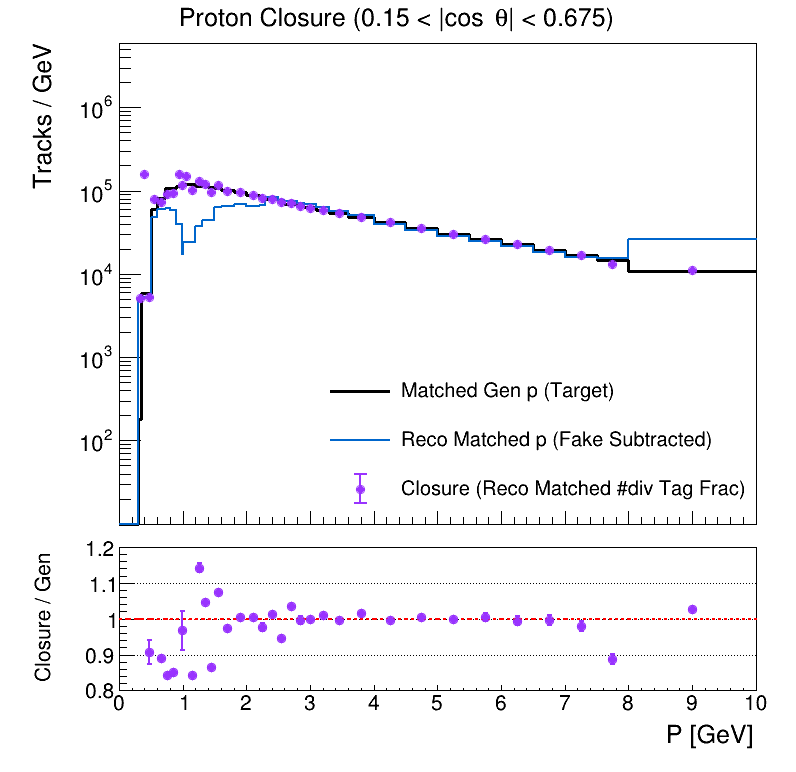

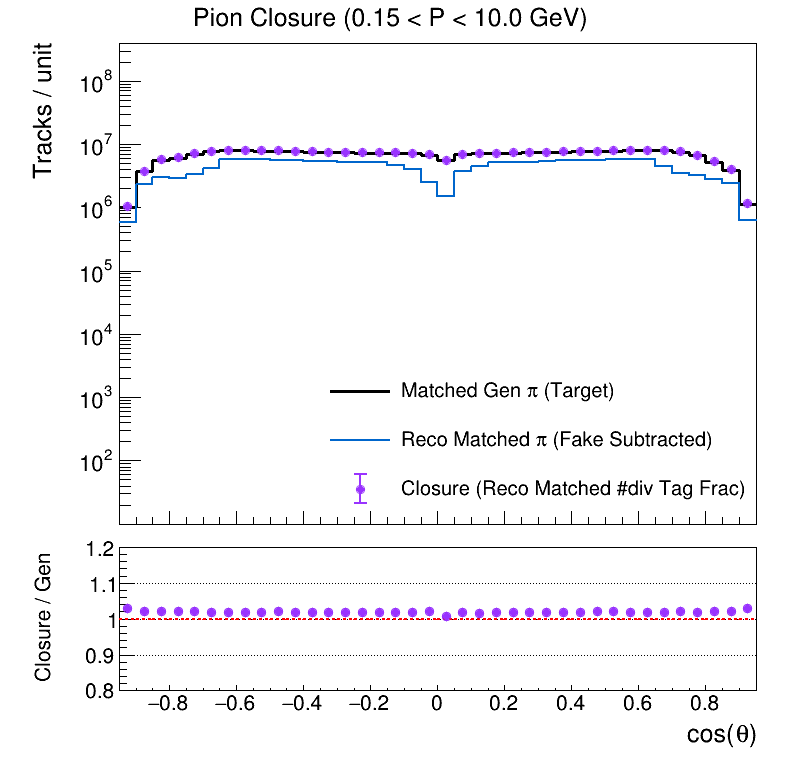

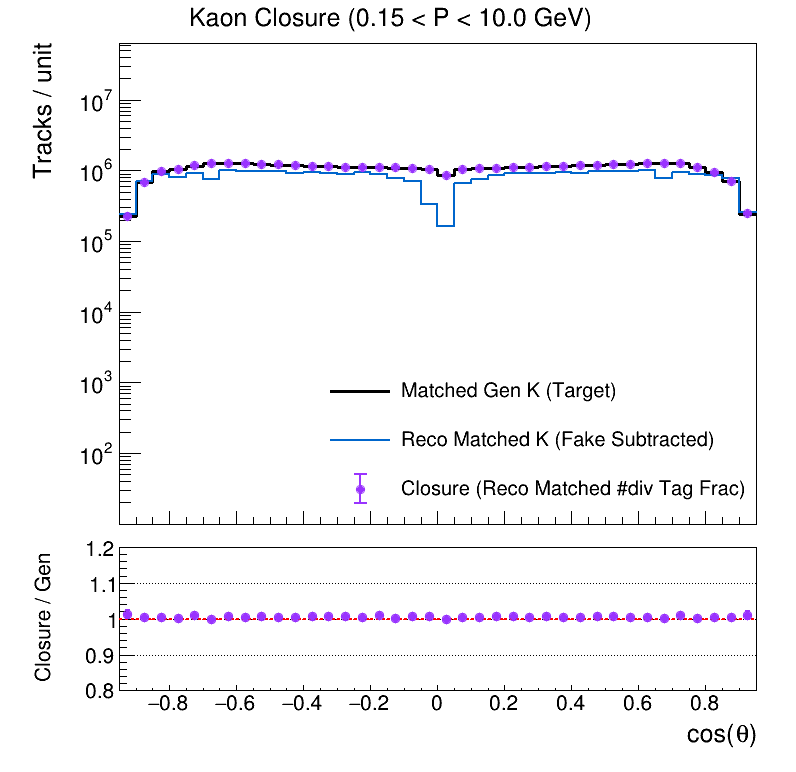

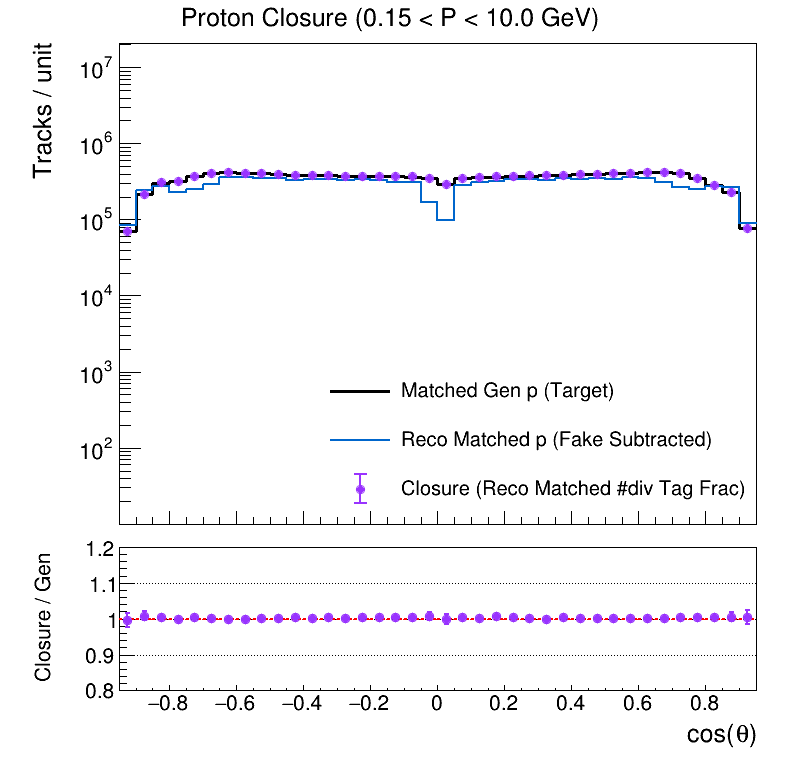

In [18]:
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(1)

ROOT.gStyle.SetErrorX(0) # Turning off horizontal error bars globally

# Bin edges
closure_p_edges = np.array([
    0.00, 0.15, 0.25, 0.30, 0.35, 0.45, 0.50, 0.60, 0.718, 0.80, 0.90, 0.99, 1.00,
    1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.80, 2.00, 2.20,
    2.30, 2.50, 2.60, 2.80, 2.90, 3.10, 3.30, 3.60, 4.00,
    4.50, 5.00, 5.50, 6.00, 6.50, 7.00, 7.50, 8.00, 10.00
], dtype=np.float64)

closure_costh_edges = np.linspace(-0.95, 0.95, 39, dtype=np.float64) # Bins of 0.05

def style_h(h, color, marker, lwidth=2):
    h.SetLineColor(color)
    h.SetMarkerColor(color)
    h.SetMarkerStyle(marker)
    h.SetMarkerSize(1.0)
    h.SetLineWidth(lwidth)

def reproject_y_xrange(h2d, new_y_edges, name, x_lo, x_hi):
    """Project Y (Momentum), slicing X (cos theta)"""
    n_new = len(new_y_edges) - 1
    h1_out = ROOT.TH1D(name, name, n_new, new_y_edges)
    h1_out.Sumw2()
    for bx in range(1, h2d.GetNbinsX() + 1):
        cx = h2d.GetXaxis().GetBinCenter(bx)
        if not (x_lo < abs(cx) < x_hi): continue
        for by in range(1, h2d.GetNbinsY() + 1):
            y_lo_src, y_hi_src = h2d.GetYaxis().GetBinLowEdge(by), h2d.GetYaxis().GetBinUpEdge(by)
            content, error = h2d.GetBinContent(bx, by), h2d.GetBinError(bx, by)
            if content == 0: continue
            width_src = y_hi_src - y_lo_src
            for b_new in range(1, n_new + 1):
                y_lo_new, y_hi_new = new_y_edges[b_new - 1], new_y_edges[b_new]
                overlap_lo, overlap_hi = max(y_lo_src, y_lo_new), min(y_hi_src, y_hi_new)
                if overlap_hi <= overlap_lo: continue
                frac = (overlap_hi - overlap_lo) / width_src
                h1_out.SetBinContent(b_new, h1_out.GetBinContent(b_new) + content * frac)
                h1_out.SetBinError(b_new, np.sqrt(h1_out.GetBinError(b_new)**2 + (error * frac)**2))
                
    # Normalize to Tracks/GeV to smooth variable binning
    h1_out.Scale(1.0, "width")
    return h1_out

def reproject_x_yrange(h2d, new_x_edges, name, y_lo, y_hi):
    """Project X (cos theta), slicing Y (Momentum)"""
    n_new = len(new_x_edges) - 1
    h1_out = ROOT.TH1D(name, name, n_new, new_x_edges)
    h1_out.Sumw2()
    for by in range(1, h2d.GetNbinsY() + 1):
        cy = h2d.GetYaxis().GetBinCenter(by)
        if not (y_lo < cy < y_hi): continue
        for bx in range(1, h2d.GetNbinsX() + 1):
            x_lo_src, x_hi_src = h2d.GetXaxis().GetBinLowEdge(bx), h2d.GetXaxis().GetBinUpEdge(bx)
            content, error = h2d.GetBinContent(bx, by), h2d.GetBinError(bx, by)
            if content == 0: continue
            width_src = x_hi_src - x_lo_src
            for b_new in range(1, n_new + 1):
                x_lo_new, x_hi_new = new_x_edges[b_new - 1], new_x_edges[b_new]
                overlap_lo, overlap_hi = max(x_lo_src, x_lo_new), min(x_hi_src, x_hi_new)
                if overlap_hi <= overlap_lo: continue
                frac = (overlap_hi - overlap_lo) / width_src
                h1_out.SetBinContent(b_new, h1_out.GetBinContent(b_new) + content * frac)
                h1_out.SetBinError(b_new, np.sqrt(h1_out.GetBinError(b_new)**2 + (error * frac)**2))
                
    # Normalize to Tracks/unit to smooth variable binning
    h1_out.Scale(1.0, "width")
    return h1_out


def build_final_closure(species, proj="P", costh_lo=0.15, costh_hi=0.675, p_lo=0.15, p_hi=10.0, MAX_WEIGHT=1000.0):
    other = [s for s in ["pion", "kaon", "proton"] if s != species]
    
    symbol_map = {"pion": "#pi", "kaon": "K", "proton": "p"}
    sp_sym = symbol_map[species]
    sp_name = species.capitalize()
    
    if proj.upper() == "P":
        edges = closure_p_edges
        projector = lambda h, name: reproject_y_xrange(h, edges, name, costh_lo, costh_hi)
        xtitle = "P [GeV]"
        ytitle = "Tracks / GeV"
        title_suffix = f"({costh_lo} < |cos#theta| < {costh_hi})"
    else:
        edges = closure_costh_edges
        projector = lambda h, name: reproject_x_yrange(h, edges, name, p_lo, p_hi)
        xtitle = "cos(#theta)"
        ytitle = "Tracks / unit"
        title_suffix = f"({p_lo} < P < {p_hi} GeV)"

    uid = f"{species}_{proj}"

    # Reco & Fakes
    h_reco    = projector(fake_hists[f"reco_{species}"], f"h_{uid}_reco")
    h_unmatch = projector(fake_hists[f"unmatched_reco_{species}"], f"h_{uid}_unmatch")
    
    h_fakerate = h_unmatch.Clone(f"h_{uid}_fakerate")
    h_fakerate.Divide(h_reco)

    # Gen & Tagged
    h_x2x = projector(pid_hists[f"matched_gen_{species}_tag_as_{species}"], f"h_{uid}_x2x")
    h_gen_tagged = h_x2x.Clone(f"h_{uid}_gen_tagged")
    for o in other:
        h_gen_tagged.Add(projector(pid_hists[f"matched_gen_{o}_tag_as_{species}"], f"h_{uid}_{o[0]}2x"))

    h_eff = projector(eff_hists[f"matched_gen_EFF_{species}"], f"h_{uid}_eff")

    # Tag Fraction/Scale Factor
    h_tag_frac = h_gen_tagged.Clone(f"h_{uid}_tagfrac")
    h_tag_frac.Divide(h_eff)
    for b in range(0, h_tag_frac.GetNbinsX() + 2):
        h_tag_frac.SetBinError(b, 0.0) 

    h_rm = h_reco.Clone(f"h_{uid}_rm")
    h_closure = h_reco.Clone(f"h_{uid}_closure")

    MIN_RATE = 1e-6
    for b in range(1, h_reco.GetNbinsX() + 1):
        rc, fb, tf = h_reco.GetBinContent(b), h_fakerate.GetBinContent(b), h_tag_frac.GetBinContent(b)
        rm = rc * (1.0 - fb)
        h_rm.SetBinContent(b, rm)

        if tf > MIN_RATE:
            weight = min(1.0 / tf, MAX_WEIGHT)
            h_closure.SetBinContent(b, rm * weight)
            
            rm_err = h_reco.GetBinError(b) * (1.0 - fb)
            cl_err = rm_err * weight
            h_closure.SetBinError(b, cl_err)
        else:
            h_closure.SetBinContent(b, 0.0)
            h_closure.SetBinError(b, 0.0)

    # Ratio Plot
    h_ratio = h_closure.Clone(f"h_{uid}_ratio")
    h_ratio.Divide(h_eff)

    
    style_h(h_eff,     ROOT.kBlack,    20, lwidth=3)
    style_h(h_rm,      ROOT.kAzure+2,  21, lwidth=2)
    # Use Solid Circles (Marker 20) for closure points
    style_h(h_closure, ROOT.kViolet+1, 20, lwidth=2)
    style_h(h_ratio,   ROOT.kViolet+1, 20, lwidth=2)

    c = ROOT.TCanvas(f"c_{uid}", f"{sp_name} {proj} Closure", 800, 800)
    
    ptop = ROOT.TPad(f"ptop_{uid}", "", 0.0, 0.30, 1.0, 1.0)
    ptop.SetBottomMargin(0.03); ptop.SetLeftMargin(0.15); ptop.SetRightMargin(0.05); ptop.SetTopMargin(0.08); ptop.SetLogy()
    ptop.Draw(); ptop.cd()

    h_eff.SetMinimum(1e1)
    h_eff.SetMaximum(h_eff.GetMaximum() * 50)
    h_eff.SetTitle(f"{sp_name} Closure {title_suffix}")
    
    h_eff.GetXaxis().SetLabelSize(0)
    h_eff.GetYaxis().SetTitle(ytitle)
    h_eff.GetYaxis().SetTitleSize(0.05)
    h_eff.GetYaxis().SetLabelSize(0.045)
    h_eff.GetYaxis().SetTitleOffset(1.2)

    h_eff.Draw("HIST")
    h_rm.Draw("HIST SAME")
    
    h_closure.Draw("E1 X0 SAME")


    leg = ROOT.TLegend(0.40, 0.05, 0.82, 0.32)
    leg.SetBorderSize(0); leg.SetFillStyle(0); leg.SetTextSize(0.04)
    leg.AddEntry(h_eff,     f"Matched Gen {sp_sym} (Target)", "l")
    leg.AddEntry(h_rm,      f"Reco Matched {sp_sym} (Fake Subtracted)", "l")
    leg.AddEntry(h_closure, f"Closure (Reco Matched #div Tag Frac)", "pe")
    leg.Draw()

    c.cd()
    
    pbot = ROOT.TPad(f"pbot_{uid}", "", 0.0, 0.0, 1.0, 0.30)
    pbot.SetTopMargin(0.03); pbot.SetBottomMargin(0.35); pbot.SetLeftMargin(0.15); pbot.SetRightMargin(0.05); pbot.SetGridy()
    pbot.Draw(); pbot.cd()
    
    h_ratio.SetTitle("")
    h_ratio.GetXaxis().SetTitle(xtitle)
    h_ratio.GetXaxis().SetTitleSize(0.12); h_ratio.GetXaxis().SetLabelSize(0.10); h_ratio.GetXaxis().SetTitleOffset(1.0)
    h_ratio.GetYaxis().SetTitle("Closure / Gen")
    h_ratio.GetYaxis().SetRangeUser(0.8, 1.2)
    h_ratio.GetYaxis().SetNdivisions(505)
    h_ratio.GetYaxis().SetTitleSize(0.10); h_ratio.GetYaxis().SetLabelSize(0.10); h_ratio.GetYaxis().SetTitleOffset(0.6)

    h_ref = h_ratio.Clone(f"ref_{uid}")
    for b in range(0, h_ref.GetNbinsX() + 2):
        h_ref.SetBinContent(b, 1.0); h_ref.SetBinError(b, 0.0)
    h_ref.SetLineColor(ROOT.kRed); h_ref.SetLineStyle(2); h_ref.SetLineWidth(2); h_ref.SetMarkerSize(0)

    h_ratio.Draw("E1 X0")
    h_ref.Draw("HIST SAME")
    h_ratio.Draw("E1 X0 SAME")
    
    c.Draw()
    keep_alive.extend([c, ptop, pbot, leg, h_reco, h_unmatch, h_fakerate, h_gen_tagged, h_eff, h_tag_frac, h_rm, h_closure, h_ratio, h_ref])
    
    eff_integral = h_eff.Integral("width")
    cl_integral  = h_closure.Integral("width")
    ratio_val    = cl_integral / eff_integral if eff_integral > 0 else 0
    print(f"[{species.upper():<6}] {proj:>5}-projection Global Ratio = {ratio_val:.4f}")
    
    return c, h_ratio


keep_alive = []

print("\n--- Generating Momentum (P) Plots ---")
c_pi_p, h_pi_p = build_final_closure("pion",   proj="P")
c_k_p,  h_k_p  = build_final_closure("kaon",   proj="P")
c_pr_p, h_pr_p = build_final_closure("proton", proj="P")

print("\n--- Generating Angular (cosTheta) Plots ---")
c_pi_ct, h_pi_ct = build_final_closure("pion",   proj="costh")
c_k_ct,  h_k_ct  = build_final_closure("kaon",   proj="costh")
c_pr_ct, h_pr_ct = build_final_closure("proton", proj="costh")